## Fase 1: Análise Exploratória e pré-processamento

### Carga dos dados + Criação do Dataframe

In [74]:
import pandas as pd

df = pd.read_csv('../data/Telco-Customer-Churn.csv')

### Limpeza de dados

In [75]:
print(f"\nTamanho do dataset antes da limpeza: {df.shape}")

# Verifica quantas linhas duplicadas existem
qtd_duplicatas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {qtd_duplicatas}")

# Converte para numérico e substitui nulos por NaN
print(f'''\nTipos antes:
{df.dtypes[['MonthlyCharges', 'TotalCharges']]}''')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'''\nTipos depois:
{df.dtypes[['MonthlyCharges', 'TotalCharges']]}''')

# Valores nulos por coluna
print(f'''\nNulos por coluna:
{df.isnull().sum()}''')

# Remove nulos
df.dropna(inplace=True)

# Remove coluna customerID
df.drop('customerID', axis=1, inplace=True)

print(f"\nTamanho do dataset após a limpeza: {df.shape}")


Tamanho do dataset antes da limpeza: (7043, 21)
Linhas duplicadas encontradas: 0

Tipos antes:
MonthlyCharges    float64
TotalCharges          str
dtype: object

Tipos depois:
MonthlyCharges    float64
TotalCharges      float64
dtype: object

Nulos por coluna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Tamanho do dataset após a limpeza: (7032, 20)


### Conversão de variáveis categóricas

In [76]:
# Dicionário para o mapeamento
mapeamento_binario = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

# Seleção de colunas binárias
colunas_binarias = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Aplicando o mapeamento
for coluna in colunas_binarias:
    df[coluna] = df[coluna].map(mapeamento_binario)

# Seleciona as colunas de texto restantes
colunas_categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Aplica o One-Hot Encoding
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# Convertendo os booleanos (True/False) gerados pelo get_dummies para 1 e 0
df = df.astype(int)


print(f"Nova quantidade de colunas: {df.shape[1]}")
display(df.head())

Nova quantidade de colunas: 31


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29,29,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56,1889,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53,108,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42,1840,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70,151,1,...,0,0,0,0,0,0,0,0,1,0


### Padronização dos dados + Divisão do dataset

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando os atributos preditivos e a resposta esperada
atributos_clientes = df.drop('Churn', axis=1)
rotulos_churn = df['Churn']

# Divisão entre dados de aprendizado e dados de validação
seed = 10
atributos_treinamento, atributos_teste, rotulos_treinamento, rotulos_teste = train_test_split(
    atributos_clientes, 
    rotulos_churn, 
    test_size=0.2, 
    random_state=seed
)

# Padronização dos dados para o algoritmo KNN
padronizador_dados = StandardScaler()
atributos_treinamento_padronizados = padronizador_dados.fit_transform(atributos_treinamento)
atributos_teste_padronizados = padronizador_dados.transform(atributos_teste)

print(f"Treinamento: {atributos_treinamento_padronizados.shape[0]} registros. Teste: {atributos_teste_padronizados.shape[0]} registros.")

Treinamento: 5625 registros. Teste: 1407 registros.


## Fase 2: Modelagem e Treinamento

### KNN (K-Nearest Neighbors)

In [78]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print("Testes de Parâmetros: Modelo KNN")
quantidades_vizinhos = [3, 5, 7]
tipos_distancia = ['euclidean', 'manhattan']

for quantidade in quantidades_vizinhos:
    for distancia in tipos_distancia:
        modelo_knn = KNeighborsClassifier(n_neighbors=quantidade, metric=distancia)
        modelo_knn.fit(atributos_treinamento_padronizados, rotulos_treinamento)
        
        acuracia_treinamento_knn = modelo_knn.score(atributos_treinamento_padronizados, rotulos_treinamento)
        acuracia_teste_knn = modelo_knn.score(atributos_teste_padronizados, rotulos_teste)
        
        nome_heuristica = "Euclidiana" if distancia == 'euclidean' else "Manhattan"
        print(f"Vizinhos={quantidade} | Distância={nome_heuristica:<10} -> Treino: {acuracia_treinamento_knn:.3f} | Teste: {acuracia_teste_knn:.3f}")

Testes de Parâmetros: Modelo KNN
Vizinhos=3 | Distância=Euclidiana -> Treino: 0.856 | Teste: 0.746
Vizinhos=3 | Distância=Manhattan  -> Treino: 0.858 | Teste: 0.758
Vizinhos=5 | Distância=Euclidiana -> Treino: 0.837 | Teste: 0.764
Vizinhos=5 | Distância=Manhattan  -> Treino: 0.836 | Teste: 0.768
Vizinhos=7 | Distância=Euclidiana -> Treino: 0.819 | Teste: 0.769
Vizinhos=7 | Distância=Manhattan  -> Treino: 0.824 | Teste: 0.771


### Árvore de Decisão

In [79]:
print("\nTestes de Parâmetros: Modelo Árvore de Decisão")
limites_profundidade = [3, 5, 10, None]

for profundidade in limites_profundidade:
        modelo_arvore_decisao = DecisionTreeClassifier(max_depth=profundidade, random_state=seed)
        modelo_arvore_decisao.fit(atributos_treinamento, rotulos_treinamento)
        
        acuracia_treinamento_arvore = modelo_arvore_decisao.score(atributos_treinamento, rotulos_treinamento)
        acuracia_teste_arvore = modelo_arvore_decisao.score(atributos_teste, rotulos_teste)
        
        texto_profundidade = "Sem limite" if profundidade is None else str(profundidade)
        print(f"Profundidade={texto_profundidade:<10} -> Treino: {acuracia_treinamento_arvore:.3f} | Teste: {acuracia_teste_arvore:.3f}")


Testes de Parâmetros: Modelo Árvore de Decisão
Profundidade=3          -> Treino: 0.788 | Teste: 0.796
Profundidade=5          -> Treino: 0.797 | Teste: 0.792
Profundidade=10         -> Treino: 0.862 | Teste: 0.759
Profundidade=Sem limite -> Treino: 0.990 | Teste: 0.741


RELATÓRIO DE MÉTRICAS - MODELO KNN
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1046
           1       0.55      0.59      0.57       361

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.78      0.77      0.77      1407


RELATÓRIO DE MÉTRICAS - ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1046
           1       0.67      0.41      0.51       361

    accuracy                           0.80      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.78      0.80      0.78      1407



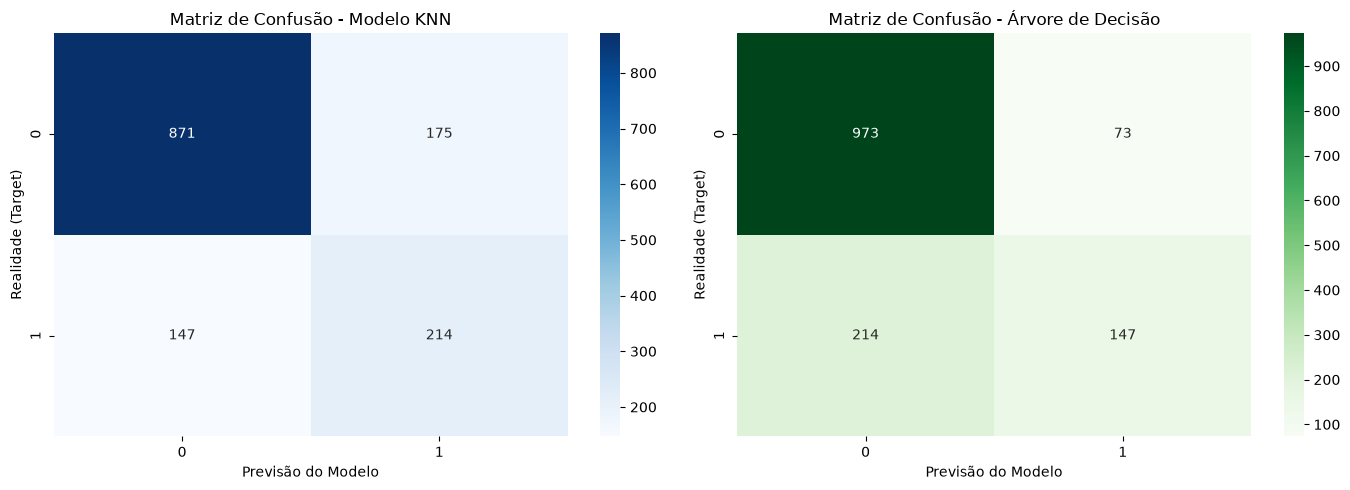

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# DEFINIÇÃO DOS MODELOS FINAIS
# Re-treinando o melhor KNN encontrado na Fase 2
modelo_knn_final = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
modelo_knn_final.fit(atributos_treinamento_padronizados, rotulos_treinamento)
previsoes_teste_knn = modelo_knn_final.predict(atributos_teste_padronizados)

# Re-treinando a melhor Árvore de Decisão encontrada na Fase 2
modelo_arvore_final = DecisionTreeClassifier(max_depth=3, random_state=seed)
modelo_arvore_final.fit(atributos_treinamento, rotulos_treinamento)
previsoes_teste_arvore = modelo_arvore_final.predict(atributos_teste)


# RELATÓRIOS DE MÉTRICAS (Acurácia, Precisão, Recall e F1-Score)
print("="*55)
print("RELATÓRIO DE MÉTRICAS - MODELO KNN")
print("="*55)
# O classification_report já calcula todas as métricas exigidas automaticamente
print(classification_report(rotulos_teste, previsoes_teste_knn))

print("\n" + "="*55)
print("RELATÓRIO DE MÉTRICAS - ÁRVORE DE DECISÃO")
print("="*55)
print(classification_report(rotulos_teste, previsoes_teste_arvore))


# MATRIZES DE CONFUSÃO
figura_matrizes, eixos_graficos = plt.subplots(1, 2, figsize=(14, 5))

# Plotando a Matriz do KNN
matriz_confusao_knn = confusion_matrix(rotulos_teste, previsoes_teste_knn)
sns.heatmap(matriz_confusao_knn, annot=True, fmt='d', cmap='Blues', ax=eixos_graficos[0])
eixos_graficos[0].set_title('Matriz de Confusão - Modelo KNN')
eixos_graficos[0].set_xlabel('Previsão do Modelo')
eixos_graficos[0].set_ylabel('Realidade (Target)')

# Plotando a Matriz da Árvore de Decisão
matriz_confusao_arvore = confusion_matrix(rotulos_teste, previsoes_teste_arvore)
sns.heatmap(matriz_confusao_arvore, annot=True, fmt='d', cmap='Greens', ax=eixos_graficos[1])
eixos_graficos[1].set_title('Matriz de Confusão - Árvore de Decisão')
eixos_graficos[1].set_xlabel('Previsão do Modelo')
eixos_graficos[1].set_ylabel('Realidade (Target)')

# Ajusta o layout para não cortar os textos e exibe o gráfico
plt.tight_layout()
plt.show()

## Rinha de Algoritmos

### KNN (K-Nearest Neighbors)

In [81]:
# Separando os atributos preditivos e a resposta esperada
atributos_clientes = df.drop('Churn', axis=1)
rotulos_churn = df['Churn']

# Média da Acurácia de treino (para checar overfitting)
medias_knn_treinamento = {
    3: {'euclidean': 0, 'manhattan': 0},
    5: {'euclidean': 0, 'manhattan': 0},
    7: {'euclidean': 0, 'manhattan': 0}
}

# Médias de teste
medias_knn_teste = {
    3: {
        'euclidean': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
        'manhattan': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0}
    },
    5: {
        'euclidean': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
        'manhattan': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0}
    },
    7: {
        'euclidean': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
        'manhattan': {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0}
    }
}

# Melhor modelo
melhor_modelo_knn = {
    'seed': 0,
    'f1_score': 0.0,
    'k': None,
    'distancia': None,
    'matriz_confusao': None
}

quantidades_vizinhos = [3, 5, 7]
tipos_distancia = ['euclidean', 'manhattan']
testes = 100

for indice in range(1, testes + 1):
    # Divisão entre dados de aprendizado e dados de validação
    atributos_treinamento, atributos_teste, rotulos_treinamento, rotulos_teste = train_test_split(
        atributos_clientes, 
        rotulos_churn, 
        test_size=0.2, 
        random_state=indice
    )
    
    # Padronização dos dados para o algoritmo KNN
    padronizador_dados = StandardScaler()
    atributos_treinamento_padronizados = padronizador_dados.fit_transform(atributos_treinamento)
    atributos_teste_padronizados = padronizador_dados.transform(atributos_teste)

    # Execução KNN
    for quantidade in quantidades_vizinhos:
        for distancia in tipos_distancia:
            modelo_knn = KNeighborsClassifier(n_neighbors=quantidade, metric=distancia)
            modelo_knn.fit(atributos_treinamento_padronizados, rotulos_treinamento)
            
            # Acurácia do treinamento
            acuracia_treinamento_knn = modelo_knn.score(atributos_treinamento_padronizados, rotulos_treinamento)
            
            # Geração das previsões
            previsoes_teste = modelo_knn.predict(atributos_teste_padronizados)
            
            # Cálculo das 4 métricas
            acc = accuracy_score(rotulos_teste, previsoes_teste)
            prec = precision_score(rotulos_teste, previsoes_teste, zero_division=0)
            rec = recall_score(rotulos_teste, previsoes_teste, zero_division=0)
            f1 = f1_score(rotulos_teste, previsoes_teste, zero_division=0)
            
            # Acúmulo das métricas
            medias_knn_treinamento[quantidade][distancia] += acuracia_treinamento_knn
            
            medias_knn_teste[quantidade][distancia]['acuracia'] += acc
            medias_knn_teste[quantidade][distancia]['precisao'] += prec
            medias_knn_teste[quantidade][distancia]['recall'] += rec
            medias_knn_teste[quantidade][distancia]['f1'] += f1

            # Atualização do melhor modelo baseada no F1-Score
            if f1 > melhor_modelo_knn['f1_score']:
                melhor_modelo_knn['seed'] = indice
                melhor_modelo_knn['f1_score'] = f1
                melhor_modelo_knn['k'] = quantidade
                melhor_modelo_knn['distancia'] = distancia
                # Armazenando a matriz de confusão exata deste cenário
                melhor_modelo_knn['matriz_confusao'] = confusion_matrix(rotulos_teste, previsoes_teste)

# Cálculo das médias finais
for quantidade in quantidades_vizinhos:
    for distancia in tipos_distancia:
        medias_knn_treinamento[quantidade][distancia] /= testes
        
        medias_knn_teste[quantidade][distancia]['acuracia'] /= testes
        medias_knn_teste[quantidade][distancia]['precisao'] /= testes
        medias_knn_teste[quantidade][distancia]['recall'] /= testes
        medias_knn_teste[quantidade][distancia]['f1'] /= testes

#### Tabela média das métricas

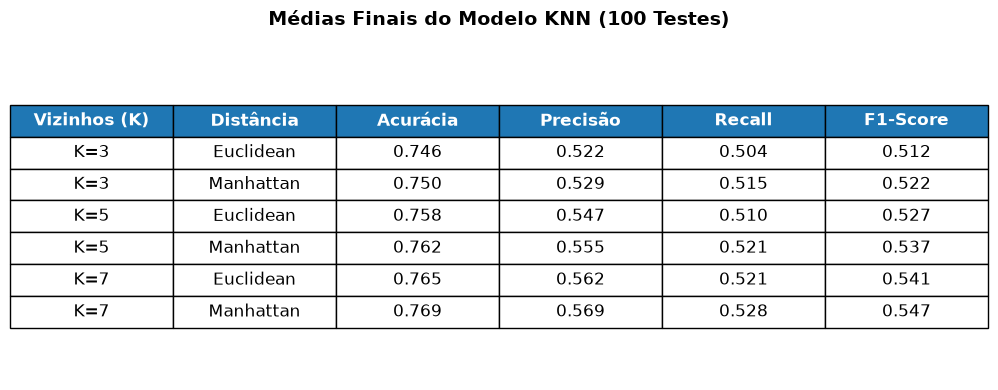

Melhor seed: 6 | F1: 0.616


In [82]:
dados_tabela = []
for quantidade in quantidades_vizinhos:
    for distancia in tipos_distancia:
        m = medias_knn_teste[quantidade][distancia]
        dados_tabela.append([
            f"K={quantidade}",
            distancia.capitalize(),
            f"{m['acuracia']:.3f}",
            f"{m['precisao']:.3f}",
            f"{m['recall']:.3f}",
            f"{m['f1']:.3f}"
        ])

colunas = ['Vizinhos (K)', 'Distância', 'Acurácia', 'Precisão', 'Recall', 'F1-Score']
df_knn = pd.DataFrame(dados_tabela, columns=colunas)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

tabela_visual = ax.table(
    cellText=df_knn.values, 
    colLabels=df_knn.columns, 
    loc='center', 
    cellLoc='center'
)

tabela_visual.auto_set_font_size(False)
tabela_visual.set_fontsize(12)
tabela_visual.scale(1.2, 1.8)

for (row, col), cell in tabela_visual.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1f77b4')
        cell.set_text_props(weight='bold', color='white')

plt.title('Médias Finais do Modelo KNN (100 Testes)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(f'Melhor seed: {melhor_modelo_knn["seed"]} | F1: {melhor_modelo_knn["f1_score"]:.3f}')

#### Matriz de confusão

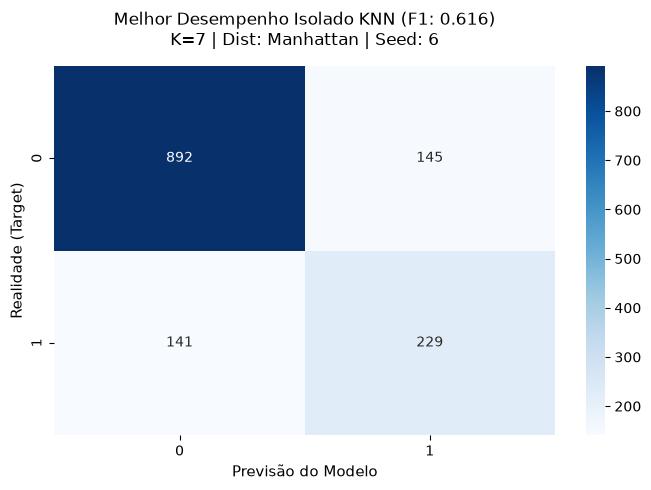

In [83]:
matriz_campea_knn = melhor_modelo_knn['matriz_confusao']
seed_campea_knn = melhor_modelo_knn['seed']
k_campeao = melhor_modelo_knn['k']
dist_campea = melhor_modelo_knn['distancia']
f1_campeao_knn = melhor_modelo_knn['f1_score']

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_campea_knn, annot=True, fmt='d', cmap='Blues')

plt.title(f'Melhor Desempenho Isolado KNN (F1: {f1_campeao_knn:.3f})\nK={k_campeao} | Dist: {dist_campea.capitalize()} | Seed: {seed_campea_knn}', fontsize=12, pad=15)
plt.xlabel('Previsão do Modelo', fontsize=11)
plt.ylabel('Realidade (Target)', fontsize=11)

plt.tight_layout()
plt.show()

### Árvore de Decisão

In [84]:
melhor_modelo_arvore = {
    'seed': 0,
    'f1_score': 0.0,
    'profundidade': None,
    'matriz_confusao': None
}

# Separando os atributos preditivos e a resposta esperada
atributos_clientes = df.drop('Churn', axis=1)
rotulos_churn = df['Churn']

limites_profundidade = [3, 5, 10, None]

# Médias da árvore de treinamento
medias_arvore_treinamento = {
    3: 0,
    5: 0,
    10: 0,
    None: 0
}

# Médias da árvore de teste expandidas para as 4 métricas
medias_arvore_teste = {
    3: {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
    5: {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
    10: {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0},
    None: {'acuracia': 0, 'precisao': 0, 'recall': 0, 'f1': 0}
}

testes = 100

for indice in range(1, testes + 1):
    # Divisão entre dados de aprendizado e dados de validação
    atributos_treinamento, atributos_teste, rotulos_treinamento, rotulos_teste = train_test_split(
        atributos_clientes, 
        rotulos_churn, 
        test_size=0.2, 
        random_state=indice
    )

    for profundidade in limites_profundidade:
        modelo_arvore_decisao = DecisionTreeClassifier(max_depth=profundidade, random_state=indice)
        modelo_arvore_decisao.fit(atributos_treinamento, rotulos_treinamento)
        
        # Acurácia do treino
        acuracia_treinamento_arvore = modelo_arvore_decisao.score(atributos_treinamento, rotulos_treinamento)
        
        # Geração das previsões para o teste
        previsoes_teste = modelo_arvore_decisao.predict(atributos_teste)

        # Cálculo das 4 métricas
        acc = accuracy_score(rotulos_teste, previsoes_teste)
        prec = precision_score(rotulos_teste, previsoes_teste, zero_division=0)
        rec = recall_score(rotulos_teste, previsoes_teste, zero_division=0)
        f1 = f1_score(rotulos_teste, previsoes_teste, zero_division=0)

        # Acúmulo no dicionário
        medias_arvore_treinamento[profundidade] += acuracia_treinamento_arvore
        medias_arvore_teste[profundidade]['acuracia'] += acc
        medias_arvore_teste[profundidade]['precisao'] += prec
        medias_arvore_teste[profundidade]['recall'] += rec
        medias_arvore_teste[profundidade]['f1'] += f1

        # Atualização do melhor modelo baseada no F1-Score
        if f1 > melhor_modelo_arvore['f1_score']:
            melhor_modelo_arvore['seed'] = indice
            melhor_modelo_arvore['f1_score'] = f1
            melhor_modelo_arvore['profundidade'] = profundidade
            # Calculamos e armazenamos a matriz de confusão exata deste cenário
            melhor_modelo_arvore['matriz_confusao'] = confusion_matrix(rotulos_teste, previsoes_teste)
        
# Divisão final para obter a média
for profundidade in limites_profundidade:
    medias_arvore_treinamento[profundidade] /= testes
    medias_arvore_teste[profundidade]['acuracia'] /= testes
    medias_arvore_teste[profundidade]['precisao'] /= testes
    medias_arvore_teste[profundidade]['recall'] /= testes
    medias_arvore_teste[profundidade]['f1'] /= testes

#### Tabela média das métricas

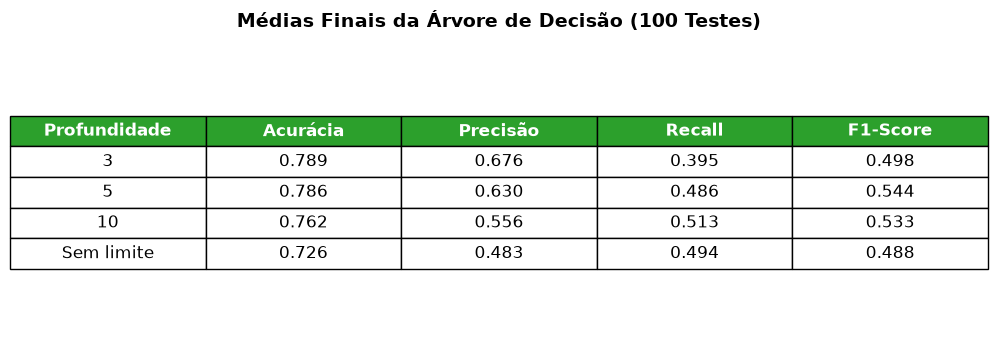

Melhor seed: 99 | F1: 0.609


In [85]:
dados_tabela_arvore = []
for profundidade in limites_profundidade:
    m = medias_arvore_teste[profundidade]
    texto_profundidade = "Sem limite" if profundidade is None else str(profundidade)
    
    dados_tabela_arvore.append([
        texto_profundidade,
        f"{m['acuracia']:.3f}",
        f"{m['precisao']:.3f}",
        f"{m['recall']:.3f}",
        f"{m['f1']:.3f}"
    ])

colunas_arvore = ['Profundidade', 'Acurácia', 'Precisão', 'Recall', 'F1-Score']
df_arvore = pd.DataFrame(dados_tabela_arvore, columns=colunas_arvore)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('tight')
ax.axis('off')

tabela_visual_arvore = ax.table(
    cellText=df_arvore.values, 
    colLabels=df_arvore.columns, 
    loc='center', 
    cellLoc='center'
)

tabela_visual_arvore.auto_set_font_size(False)
tabela_visual_arvore.set_fontsize(12)
tabela_visual_arvore.scale(1.2, 1.8)

for (row, col), cell in tabela_visual_arvore.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2ca02c') 
        cell.set_text_props(weight='bold', color='white')

plt.title('Médias Finais da Árvore de Decisão (100 Testes)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(f'Melhor seed: {melhor_modelo_arvore["seed"]} | F1: {melhor_modelo_arvore["f1_score"]:.3f}')

#### Matriz de confusão

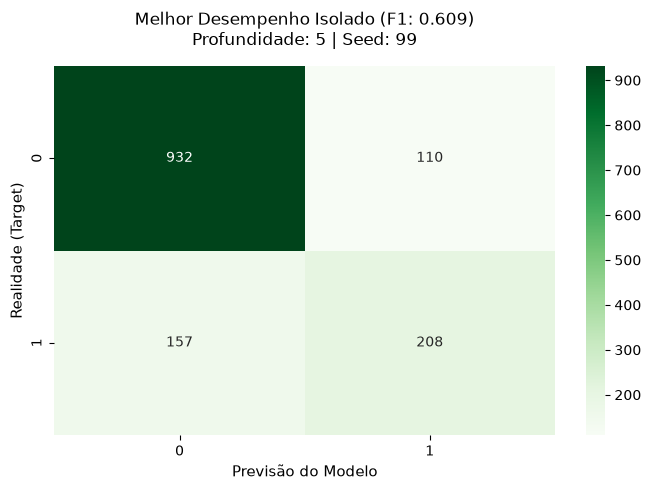

In [86]:
matriz_campea = melhor_modelo_arvore['matriz_confusao']
seed_campea = melhor_modelo_arvore['seed']
prof_campea = melhor_modelo_arvore['profundidade']
f1_campeao = melhor_modelo_arvore['f1_score']

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_campea, annot=True, fmt='d', cmap='Greens')

plt.title(f'Melhor Desempenho Isolado (F1: {f1_campeao:.3f})\nProfundidade: {prof_campea} | Seed: {seed_campea}', fontsize=12, pad=15)
plt.xlabel('Previsão do Modelo', fontsize=11)
plt.ylabel('Realidade (Target)', fontsize=11)

plt.tight_layout()
plt.show()